В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням Decision Trees і зробимо новий submission на змагання на Kaggle.

В цьому ДЗ ми працюємо без pipelines, бо так буде зручніше для візуалізації і інтерпретації моделі дерева прийняття рішень. Так буває і в робочих проєктах: іноді зручніше використати sklearn.Pipelines, іноді зручніше без них. На етапі пошуку рішення (research) зручніше без пайплайнів, а з пайплайнами - коли ви відлагодили процес обробки даних і хочете поекспериментувати з різними моделями і гіперпараметрами.

**Завдання 1.**

У попередньому домашньому завданні, `HW 2.7 Логістична регресія з scikit learn.ipynb`, ми писали обробку даних для змагання. Ваше завдання зараз - за прикладом, наведеним в лекції `Майстер-клас з перенесення коду з jupyter notebook у Python модуль`, перенести попередню обробку сирих даних з вашого розв'язку ДЗ 2.7 у файл `process_bank_churn.py` в функцію `preprocess_data(...)`.

Функція `preprocess_data()` має приймати `raw_df` і вертати `X_train`, `train_targets`, `X_val`, `val_targets`, `input_cols`(перелік назв колонок, які Ви використовуєте в X), `scaler`, `encoder`, які ми потім будемо використовувати для тренування дерева прийняття рішень.


### Кроки попередньої обробки:

1. Обираємо колонки для роботи. В цьому завдання для чистоти експериментів рекомендую прибрати колонку `Surname`, так буде простіше інтрепретувати модель. Ви можете її додати вже за самостійних подальших експериментів.
2. Розбиття сирих даних на тренувальні і валідаційні.
3. Обробка категоріальних даних (one hot encoding).
4. Масштабування числових даних (було частиною попередньої обробки в попередніх завданнях). Для дерев нам не обовʼязково масштабувати ознаки, тож в коді можна зробити цю частину опціональною, додавши в `preprocess_data` параметр `scaler_numeric`, який приймає значення `True` або `False`. Це дозволить використовувати код попередньоъ обробки з різними моделями.


### Інструкції:
1. Перенесіть попередню обробку даних у файл `process_bank_churn.py`.
2. Забезпечте модулярну структуру функцій: кожна функція повинна виконувати лише одну дію, наприклад, масштабувати ознаки.
3. Додайте докстрінги до кожної функції.
4. Використовуйте typing для аргументів та значень, що повертаються функціями.
5. Передбачте обробку нових даних. Додайте спеціальну функцію `preprocess_new_data(...)`, яка приймає на вхід нові дані в вигляді pandas DataFrame та використовує вже навчені скейлер та енкодер (передані теж як аргументи фукнціх) для їх обробки. Ця функція буде корисною для обробки нових даних перед передбаченням або оцінкою моделі, коли оброблятимемо `test.csv`.

Можна і рекомендовано виконувати це завдання з ChatGPT (бажано, новіше, ніж 3.5) як було наведено у відео-прикладі, тільки **ваше додаткове завдання - розібратись з кодом, який вам згенерувала мовна модель :)**.

## В результаті цього завдання

1. Завантажте ваш готовий `process_bank_churn.py` файл на GitHub у свій репозиторій.
2. Додайте посилання на файл в репозиторії тут у ноутбуці.
3. Нижче зробіть імпорт функції `preprocess_data` з вашого модуля `process_bank_churn.py`.



2. link to the file: https://github.com/Katkova/DS_course/blob/main/process_bank_churn.py

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
data_dir = '/content/drive/MyDrive/ML1/data/kaggle_data'

In [14]:
import os

print(os.listdir('/content/drive/MyDrive/ML1'))

['Test1.ipynb', 'data', 'process_bank_churn.py']


In [15]:
import sys, importlib
sys.path.append('/content/drive/MyDrive/ML1')
importlib.invalidate_caches()        # скинути закешований список файлів у шляхах

from process_bank_churn import preprocess_data, preprocess_new_data
print('ok')

ok


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import roc_auc_score

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [20]:
raw_df = pd.read_csv(f'{data_dir}/train.csv')
data = preprocess_data(raw_df, scaler_numeric=False)   # дереву скейлер не потрібен

print(data['X_train'].shape, data['X_val'].shape)
print(data['input_cols'])
print('scaler:', data['scaler'])

(12000, 13) (3000, 13)
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_France', 'Geography_Germany', 'Geography_Spain', 'Gender_Female', 'Gender_Male']
scaler: None


**Завдання 2.**
1. Натренуйте дерево прийняття рішень з зафіксованим `random_state` і з рештою аргументів за замовченням.
2. Виведіть area under ROC для моделі на тренувальних і тестувальних даних. Нам потрібна ця метрика, бо вона основна в змаганні. Модель ок, чи є пере- або недотренування?
3. Виведіть глибину дерева.
4. Побудуйте дерево до глибини 2 включно. Напишіть, які ознаки бачите, що є найвпливовішими тут?
5. Створіть датафрейм `importance_df` з feature importances, де в першому стовпчику `feature` - назва ознаки з нашого Х, а в другому `importance` - значення, наскільки ця ознака є важливою в побудованій моделі. Виведіть топ 10 найвпливовіших ознак разом з їх скором важливості (можна або у вигляді таблиці, або в вигляді barplot).

In [22]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, train_targets)

DecisionTreeClassifier(random_state=42)

In [23]:
# 2 AUROC — від ймовірностей, не від міток
train_auc = roc_auc_score(train_targets, model.predict_proba(X_train)[:, 1])
val_auc   = roc_auc_score(val_targets,   model.predict_proba(X_val)[:, 1])
print(f'Train AUROC: {train_auc:.4f}')
print(f'Val AUROC:   {val_auc:.4f}')

Train AUROC: 1.0000
Val AUROC:   0.7700


модель перетренована. На тренувальних даних AUROC = 1ю

In [25]:
# 3 глибина
print('Depth:', model.tree_.max_depth)

print('Листів:', model.get_n_leaves())
print('Вузлів:', model.tree_.node_count)

Depth: 26
Листів: 1332
Вузлів: 2663


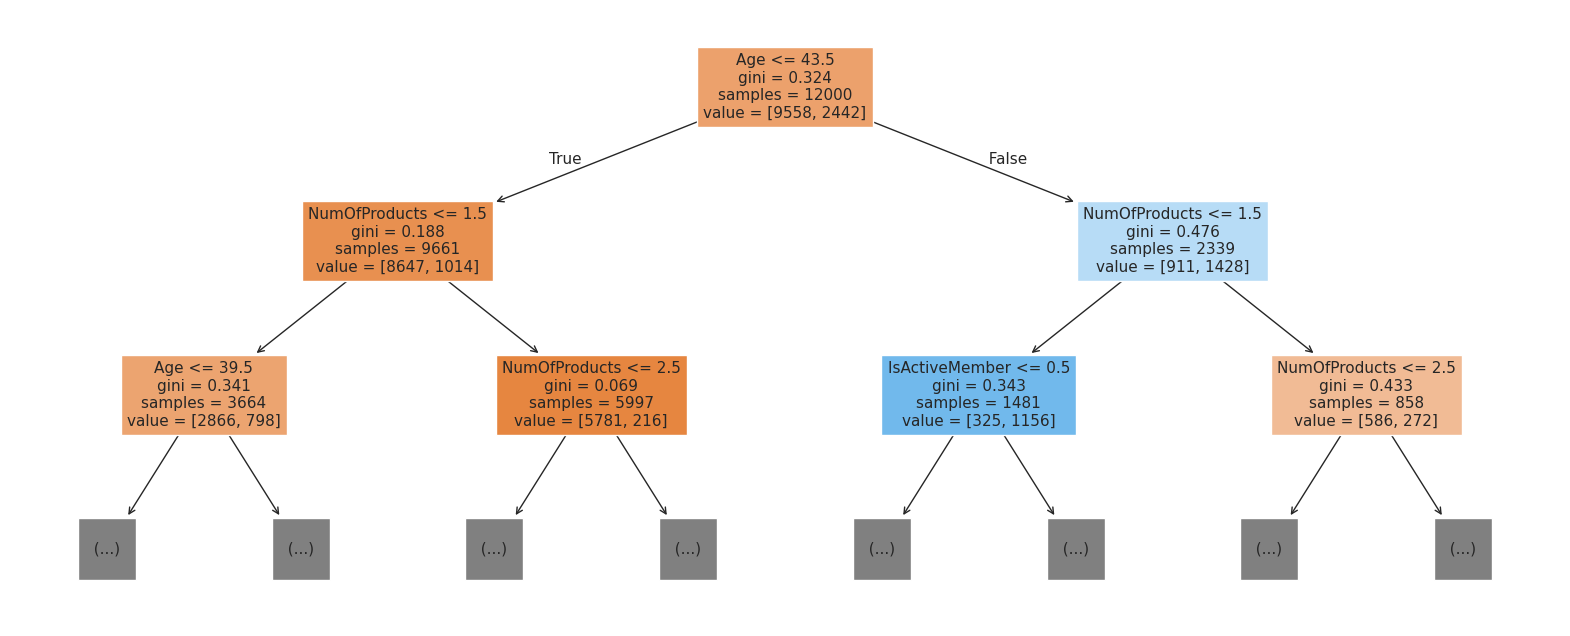

In [28]:
# 4 дерево до глибини 2 включно
from sklearn.tree import plot_tree, export_text

plt.figure(figsize=(20,8))
plot_tree(model, feature_names=X_train.columns, max_depth=2, filled=True);

First two levels of the tree are: Age and NumOfProducts. Age is the most important divider. Cleanest node is gini = 0.069 with age under 43.5 and products over 1.5 eg 2.

,feature,importance
1,Age,0.356789
4,NumOfProducts,0.168379
7,EstimatedSalary,0.123635
0,CreditScore,0.123283
3,Balance,0.079192
2,Tenure,0.052899
6,IsActiveMember,0.032688
11,Gender_Female,0.014908
9,Geography_Germany,0.014725
5,HasCrCard,0.012957


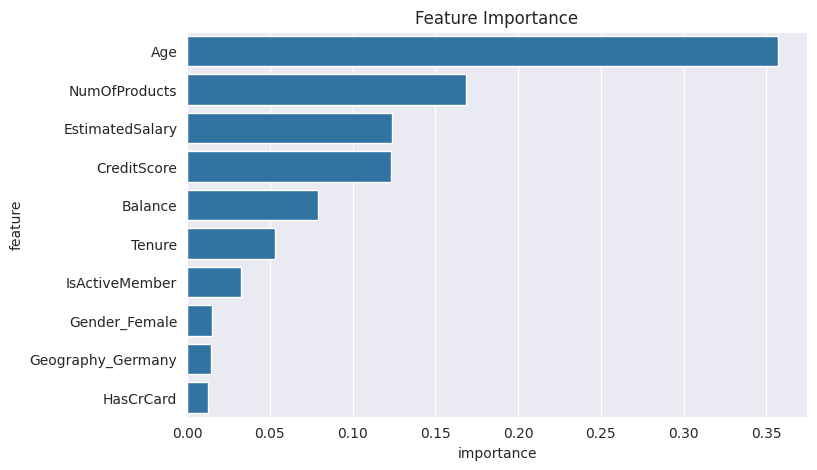

In [29]:
# 5
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

display(importance_df.head(10))

plt.figure(figsize=(8, 5))
plt.title('Feature Importance')
sns.barplot(data=importance_df.head(10), x='importance', y='feature')
plt.show()

In [33]:
#check
np.isclose(importance_df['importance'].sum(), 1.0)

np.True_

**Завдання 3**. Спробуйте знайти такі параметри моделі `DecisionTree` аби модель генералізувала ліпше (був вищий показник AUROC на валідаційній вибірці). Проекспериментуйте з різними значеннями параметрів `max_leaf_nodes`, `max_depth` та лишіть ті, які дають найкращий результат, разом з відповідними AUROC на тренувальній і валідаційній вибірках.

В цьому завданні спробуйте просто знайти параметри методом "тика" :)

In [34]:
def try_tree(max_depth=None, max_leaf_nodes=None):
    m = DecisionTreeClassifier(
        max_depth=max_depth,
        max_leaf_nodes=max_leaf_nodes,
        random_state=42
    ).fit(X_train, train_targets)

    train_auc = roc_auc_score(train_targets, m.predict_proba(X_train)[:, 1])
    val_auc   = roc_auc_score(val_targets,   m.predict_proba(X_val)[:, 1])

    print(f'depth={max_depth}, leaves={max_leaf_nodes} -> '
          f'train {train_auc:.4f} | val {val_auc:.4f}')
    return m

In [35]:
try_tree(max_depth=3)

depth=3, leaves=None -> train 0.8972 | val 0.8911


DecisionTreeClassifier(max_depth=3, random_state=42)

In [41]:
try_tree(max_depth=4)

depth=4, leaves=None -> train 0.9113 | val 0.9113


DecisionTreeClassifier(max_depth=4, random_state=42)

In [36]:
try_tree(max_depth=5)

depth=5, leaves=None -> train 0.9257 | val 0.9219


DecisionTreeClassifier(max_depth=5, random_state=42)

In [40]:
try_tree(max_depth=6)

depth=6, leaves=None -> train 0.9338 | val 0.9211


DecisionTreeClassifier(max_depth=6, random_state=42)

In [37]:
try_tree(max_depth=7)

depth=7, leaves=None -> train 0.9415 | val 0.9144


DecisionTreeClassifier(max_depth=7, random_state=42)

In [38]:
try_tree(max_depth=10)

depth=10, leaves=None -> train 0.9698 | val 0.8484


DecisionTreeClassifier(max_depth=10, random_state=42)

In [39]:
try_tree(max_depth=15)

depth=15, leaves=None -> train 0.9983 | val 0.7956


DecisionTreeClassifier(max_depth=15, random_state=42)

In [42]:
_ = try_tree(max_leaf_nodes=16)
_ = try_tree(max_leaf_nodes=32)
_ = try_tree(max_leaf_nodes=64)

depth=None, leaves=16 -> train 0.9145 | val 0.9136
depth=None, leaves=32 -> train 0.9221 | val 0.9187
depth=None, leaves=64 -> train 0.9331 | val 0.9191


In [43]:
_ = try_tree(max_depth=5, max_leaf_nodes=24)
_ = try_tree(max_depth=6, max_leaf_nodes=32)
_ = try_tree(max_leaf_nodes=96)

depth=5, leaves=24 -> train 0.9223 | val 0.9200
depth=6, leaves=32 -> train 0.9271 | val 0.9230
depth=None, leaves=96 -> train 0.9369 | val 0.9132


In [44]:
_ = try_tree(max_depth=6, max_leaf_nodes=24)
_ = try_tree(max_depth=6, max_leaf_nodes=40)
_ = try_tree(max_depth=7, max_leaf_nodes=32)

depth=6, leaves=24 -> train 0.9196 | val 0.9175
depth=6, leaves=40 -> train 0.9291 | val 0.9219
depth=7, leaves=32 -> train 0.9220 | val 0.9188


Перебором знайдено, що найкраща комбінація max_depth=6, max_leaf_nodes=32:
train AUROC = 0.9271, val AUROC = 0.9230.

Для порівняння: дефолтне дерево (глибина 26) дає train 1.0000 / val 0.7700 — розрив 0.23, класичне перенавчання.

**Завдання 4**. В циклі пройдіться по значенням max_depth від 1 до 20 включно, на кожній ітерації натренуйте DecisionTree модель і виміряйте AUROC на трейн і валідаційних даних.

В кінці виведіть на графік залеєність між AUROC на трейн і валідаційних даних і номером ітерації.

In [45]:
results = []
for depth in range(1, 21):
    m = DecisionTreeClassifier(max_depth=depth, random_state=42).fit(X_train, train_targets)
    results.append({
        'max_depth': depth,
        'train_auc': roc_auc_score(train_targets, m.predict_proba(X_train)[:, 1]),
        'val_auc':   roc_auc_score(val_targets,   m.predict_proba(X_val)[:, 1]),
    })

results_df = pd.DataFrame(results)

max_depth    5.000000
train_auc    0.925694
val_auc      0.921927
Name: 4, dtype: float64


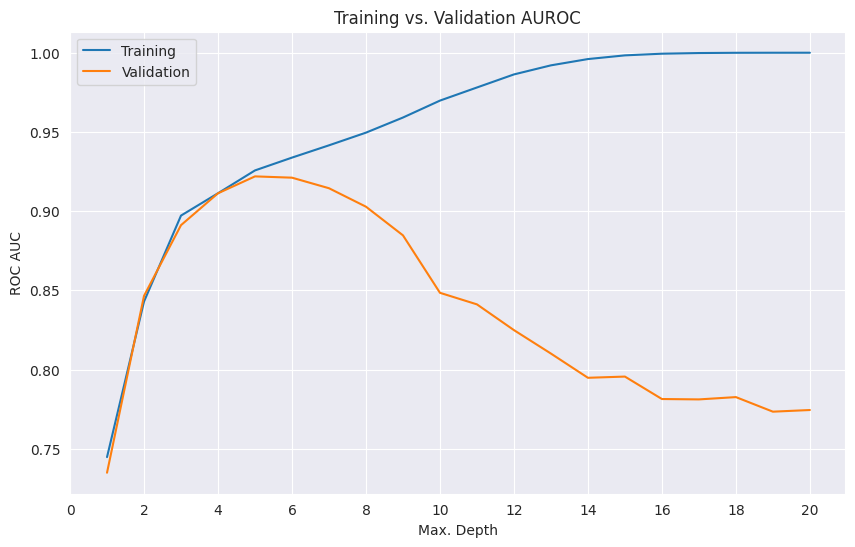

In [47]:
plt.figure()
plt.plot(results_df['max_depth'], results_df['train_auc'])
plt.plot(results_df['max_depth'], results_df['val_auc'])
plt.title('Training vs. Validation AUROC')
plt.xticks(range(0,21, 2))
plt.xlabel('Max. Depth')
plt.ylabel('ROC AUC')
plt.legend(['Training', 'Validation'])

best = results_df.loc[results_df['val_auc'].idxmax()]
print(best)

**Завдання 5**.
1. Натренуйте модель `DecisionTree` з найкращим значенням `max_depth`, яке ви знайшли на попередній ітерації.
2. Завантажте тестові дані змагання з `test.csv`.
3. Зробіть попередню обробку даних з функцією `preprocess_new_data` з вашого модуля `process_bank_churn.py`.
4. Зробіть передбачення використовуючи цю модель на тестових даних змагання.
5. Сформуйте `submission.csv`.
6. Зробіть новий Submission на Kaggle і додайте тут скріншот Вашого скору на паблік лідерборді :)


In [48]:
# 1 Фінальна модель — найкращі параметри із Завдання #3
final_model = DecisionTreeClassifier(max_depth=6, max_leaf_nodes=32, random_state=42)
final_model.fit(X_train, train_targets)

print('train AUROC:', round(roc_auc_score(train_targets, final_model.predict_proba(X_train)[:, 1]), 4))
print('val AUROC:  ', round(roc_auc_score(val_targets,   final_model.predict_proba(X_val)[:, 1]), 4))

train AUROC: 0.9271
val AUROC:   0.923


In [49]:
# 2-3 Тестові дані і препроцесинг вже навченими об'єктами
test_raw_df = pd.read_csv(f'{data_dir}/test.csv')

X_test = preprocess_new_data(
    test_raw_df,
    input_cols=data['input_cols'],
    scaler=data['scaler'],
    encoder=data['encoder'],
    numeric_cols=data['numeric_cols'],
    categorical_cols=data['categorical_cols'],
)

# перевірки перед передбаченням
assert list(X_test.columns) == data['input_cols'], 'порядок колонок не збігається!'
print(X_test.shape, X_train.shape[1], 'колонок очікується')
print('пропусків:', X_test.isna().sum().sum())

(10000, 13) 13 колонок очікується
пропусків: 0


In [50]:
# 4-5 Передбачення і submission
test_raw_df['Exited'] = final_model.predict_proba(X_test)[:, 1]

submission = pd.read_csv(f'{data_dir}/sample_submission.csv')
submission['Exited'] = submission['id'].map(test_raw_df.set_index('id')['Exited'])

# контроль перед збереженням
print('порожніх значень:', submission['Exited'].isna().sum())
display(submission.head())
print(submission['Exited'].describe())

submission.to_csv('submission_tree.csv', index=False)

порожніх значень: 0


,id,Exited
0,15000,0.171206
1,15001,0.014371
2,15002,0.014371
3,15003,0.770925
4,15004,0.014371


count    10000.000000
mean         0.208646
std          0.300572
min          0.000000
25%          0.014371
50%          0.041734
75%          0.281059
max          1.000000
Name: Exited, dtype: float64


In [51]:
from google.colab import files
files.download('submission_tree.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>